# Chromosome IV Replicate 2 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

_, config = load_default_chrom_configs()
config.shift_parameters_for_alpha()

real_deconv2 = RealDataReplicationDeconvolution(config, replicate=2, chr=4)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [3]:
real_deconv2.update_parameters({'mu0': 20.02,
 'delta': 9.15,
 'sigma0': 3.92,
 'sigmav': 0.115,
 'lambda': 59,
 'gamma1': 0.6629525211716354,
 'gamma2': 1.0,
 'halted': 0,
 'alpha': 20})


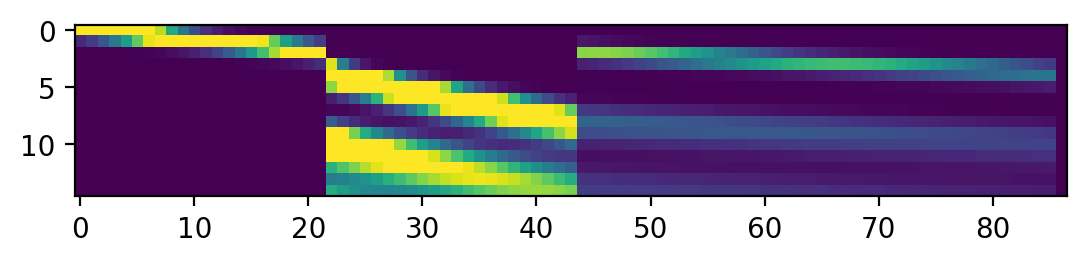

In [4]:
plt.imshow(real_deconv2.config.H, vmax=0.05)

In [5]:
from src.optimize_H import ParameterOptimizer, create_bounds_params_from_config, run_epochs

params_df = create_bounds_params_from_config(real_deconv2.config)

In [6]:
real_deconv2.setup_deconvolution(real_deconv2.config)

Initializing N using config H.
Initializing B using timepoint 0


In [7]:
real_deconv2.iterative_deconvolution_updates(20, verbose=False)

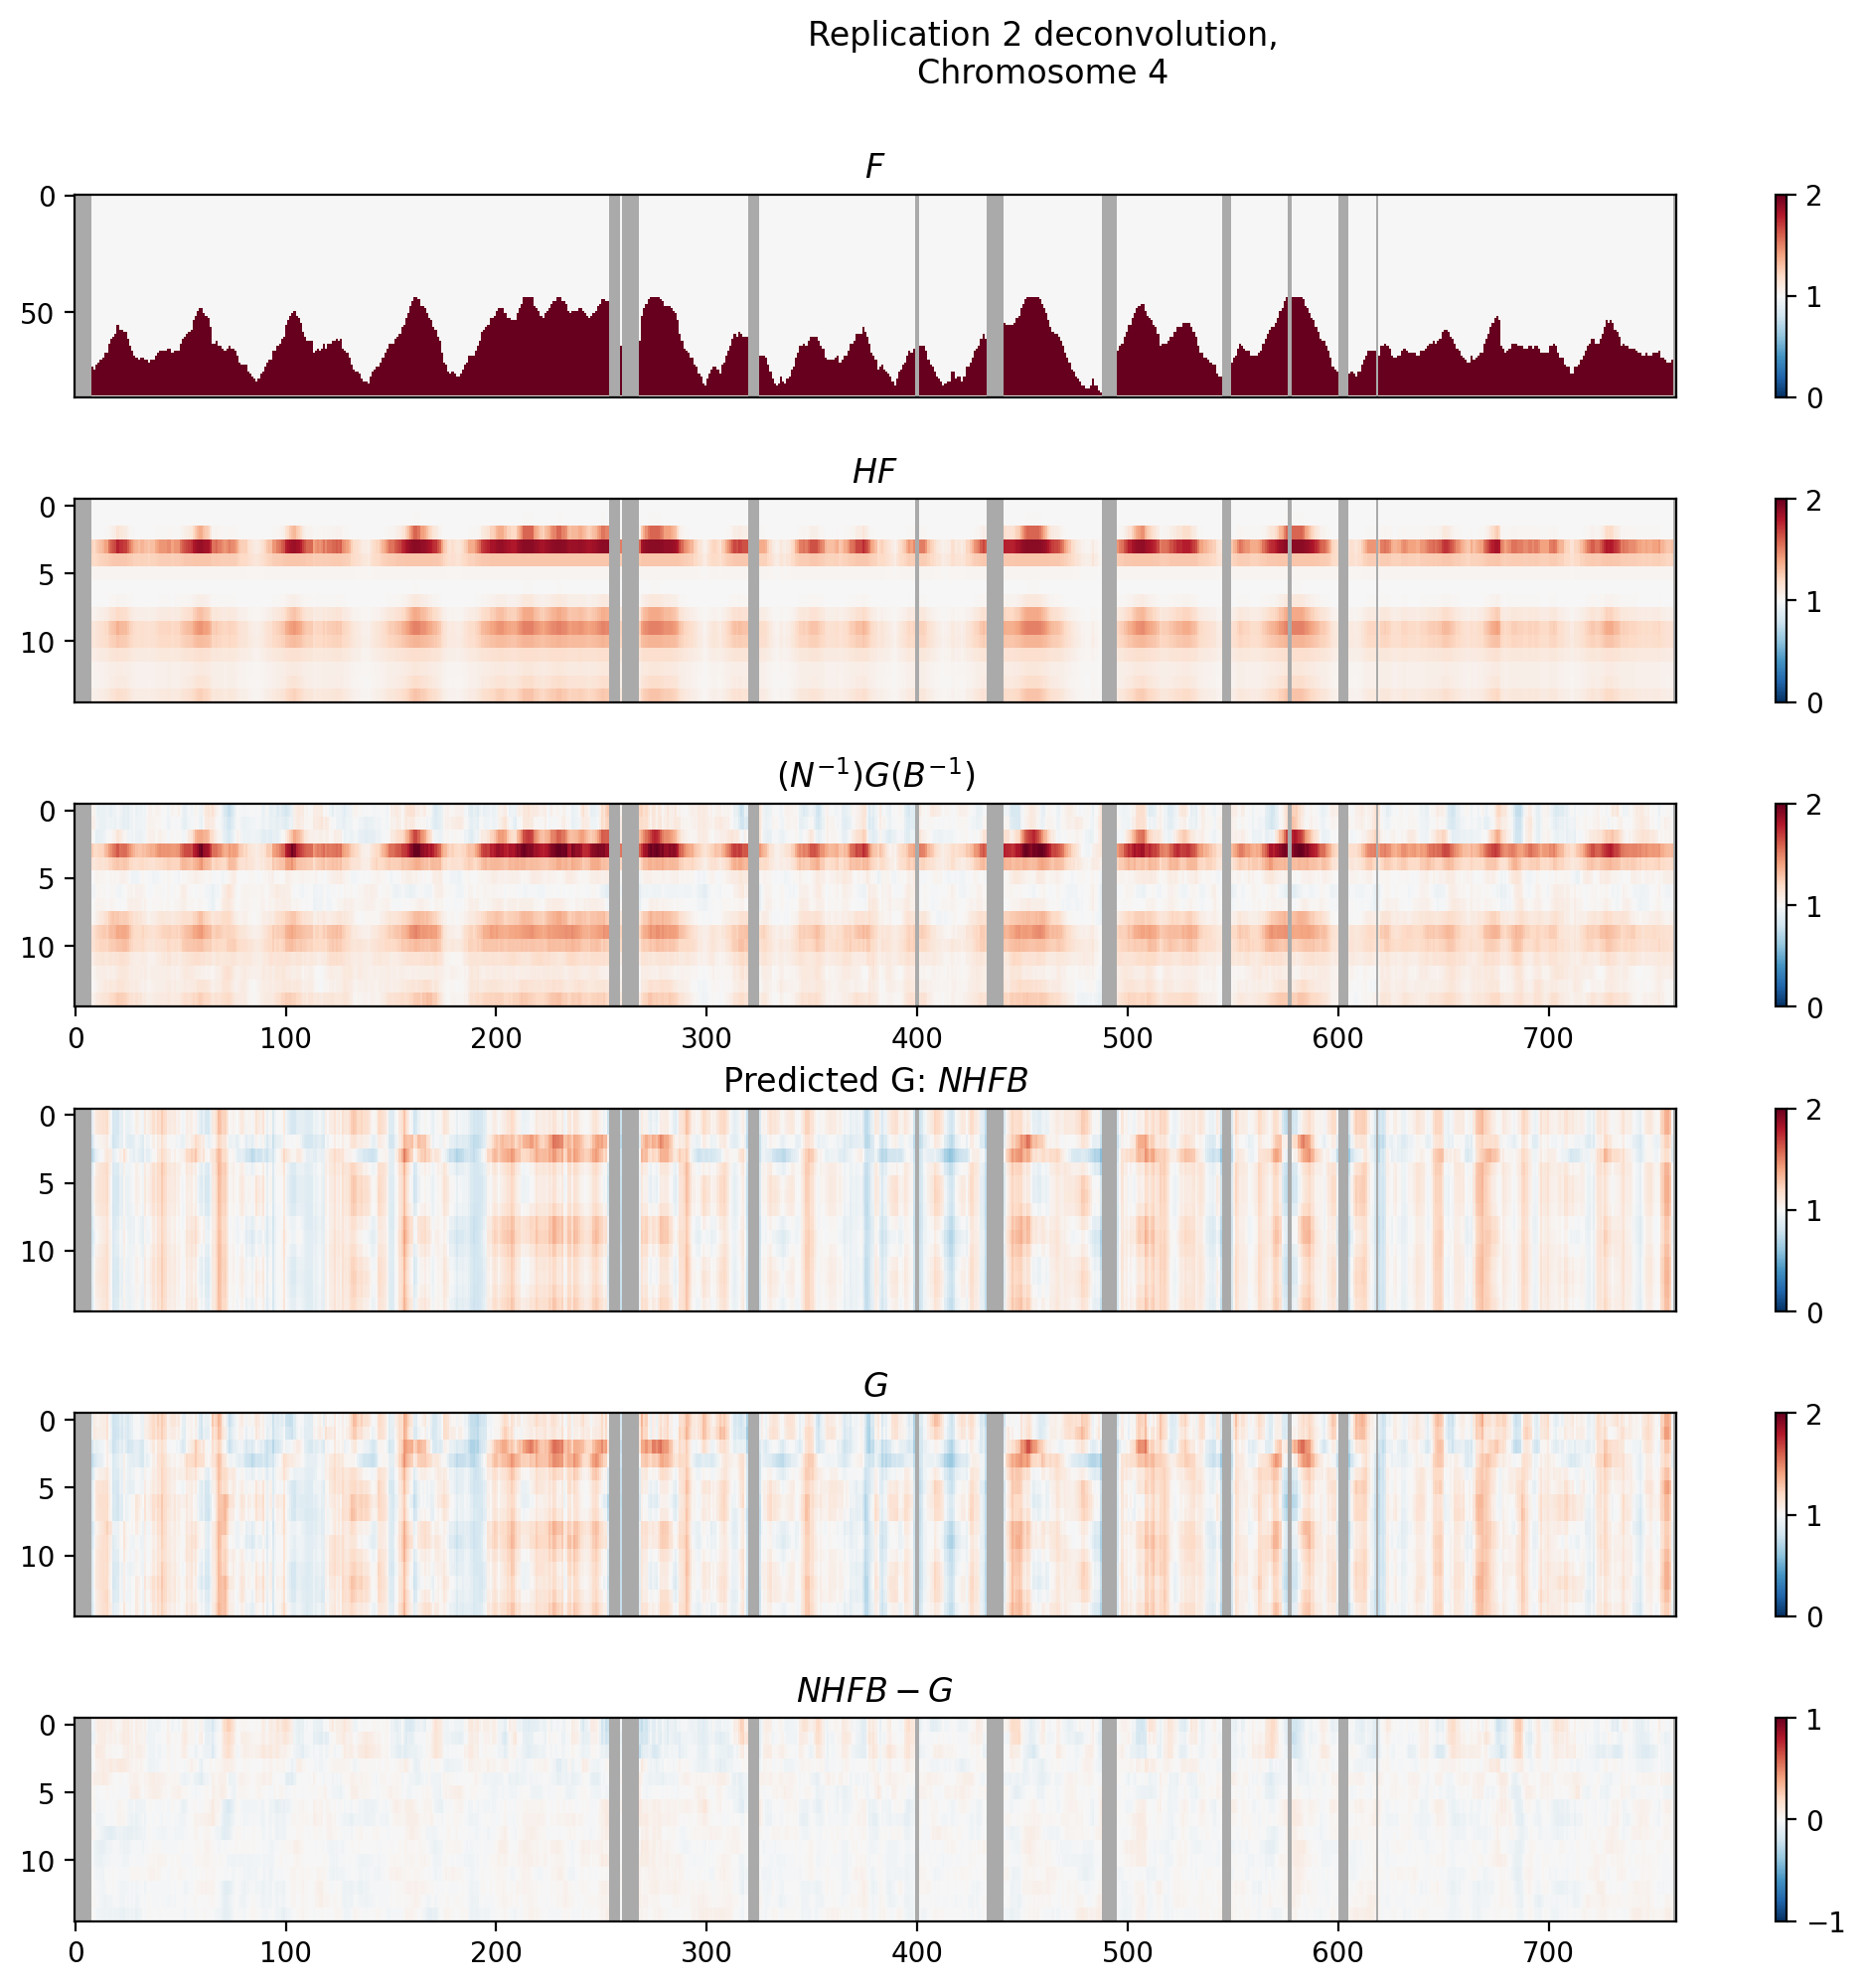

In [8]:
real_deconv2.plot_heatmaps()

In [ ]:
update_params_df, Hs, Fs, Ns, Bs = run_epochs(real_deconv2, params_df, 100)

Epoch:  0
Optimization [1]: Current loss: 0.0018261296853036954
Optimization [101]: Current loss: 0.0018109999781865938
Optimization [201]: Current loss: 0.001809998148318179
Optimization [301]: Current loss: 0.0018056327289612659
Optimization [401]: Current loss: 0.0018028808618288025
Optimization [501]: Current loss: 0.001802602481456168
Optimization [601]: Current loss: 0.0018026002703801587
Optimization terminated successfully.
         Current function value: 0.001803
         Iterations: 405
         Function evaluations: 615
00:03:00.667
mu0           24.748084
lambda        63.653718
delta          0.400797
sigma0         3.933011
sigmav         0.127759
gamma1         0.684550
gamma2         1.000000
halted         0.001918
opt_H_loss     0.001803
F_rn           0.001793
Name: 0, dtype: float64
Epoch:  1
Optimization [1]: Current loss: 0.001792839714630456
Optimization [101]: Current loss: 0.0017866685271947832
Optimization terminated successfully.
         Current function va

Optimization terminated successfully.
         Current function value: 0.001778
         Iterations: 286
         Function evaluations: 450
00:22:21.049
mu0           2.550611e+01
lambda        6.473456e+01
delta         1.059797e-02
sigma0        4.391536e+00
sigmav        1.380728e-01
gamma1        6.757207e-01
gamma2        1.000000e+00
halted        1.188708e-08
opt_H_loss    1.777529e-03
F_rn          1.777412e-03
Name: 15, dtype: float64
Epoch:  16
Optimization [1]: Current loss: 0.001777412307660748
Optimization [101]: Current loss: 0.001777328478306712
Optimization terminated successfully.
         Current function value: 0.001777
         Iterations: 60
         Function evaluations: 112
00:23:25.841
mu0           2.549259e+01
lambda        6.474328e+01
delta         1.040870e-02
sigma0        4.400727e+00
sigmav        1.383031e-01
gamma1        6.752891e-01
gamma2        1.000000e+00
halted        1.202590e-08
opt_H_loss    1.777314e-03
F_rn          1.777276e-03
Name: 16, d

Optimization [1]: Current loss: 0.0017747979167571934
Optimization terminated successfully.
         Current function value: 0.001775
         Iterations: 47
         Function evaluations: 93
00:38:11.777
mu0           2.523406e+01
lambda        6.479567e+01
delta         1.020720e-02
sigma0        4.526638e+00
sigmav        1.398558e-01
gamma1        6.686672e-01
gamma2        1.000000e+00
halted        1.286347e-08
opt_H_loss    1.774758e-03
F_rn          1.774726e-03
Name: 31, dtype: float64
Epoch:  32
Optimization [1]: Current loss: 0.001774726424054809
Optimization [101]: Current loss: 0.001774694765667686
Optimization terminated successfully.
         Current function value: 0.001775
         Iterations: 53
         Function evaluations: 103
00:39:18.981
mu0           2.521230e+01
lambda        6.479205e+01
delta         1.018676e-02
sigma0        4.533439e+00
sigmav        1.398844e-01
gamma1        6.683271e-01
gamma2        1.000000e+00
halted        1.310677e-08
opt_H_loss   

In [ ]:
config.params_dic

In [ ]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

In [ ]:
plt.imshow(real_deconv2.H, vmax=0.05)

In [ ]:
real_deconv2.plot_heatmaps()

In [ ]:
from src.chromatin_model import draw_phase_label_annotations

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv2.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 2, chrIV")

# Plot when 95% of the genome has been replicated
x, y = t_tps, real_deconv2.F.mean(axis=1)[t_indices]
g2m_start = t_tps[y > 1.95][0]
plt.axvline(g2m_start)
config.params_dic['lambda'] - g2m_start